# EMC Enrichment Branch Coverage

For each decision point in the pipeline, shows how many of the EMC planet-rows
go through each branch. Stellar parameters ($T_{\mathrm{eff}}$, $R_\star$, $M_\star$)
come from four tiers in priority order:
**NEA** (`pscomppars.txt`), **EPIC** (`k2pandc.txt`), **TOI** (`toi_init.txt`),
and **SIMBAD** (`simbad_params.txt`) as fallback.
Run cells in order: **setup → diagram → statistics → figure**.

---
**References**  
[1] Chen & Kipping 2017, *ApJ* **834**, 17 — piecewise power-law mass–radius relation  
[2] Stevens & Gaudi 2013, *PASP* **125**, 933 — isotropic orbital inclination prior for RV detections  
[3] Kopparapu et al. 2013, *ApJ* **765**, 131 — conservative habitable-zone flux boundaries


In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, pathlib

ROOT = pathlib.Path.cwd()
while not (ROOT / 'crossmatching').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import MaskedColumn

from crossmatching import EMCCatalog
from crossmatching.enrichment import (
    ParamFiller,
    rocky_mask,
    temperate_mask,
    NeaParamSource,
    EuParamSource,
    EpicParamSource,
    ToiParamSource,
    SimbadParamSource,
)

emc = EMCCatalog().load(from_file='input/exo-mercat.csv', format='csv')

# ── Tier 1: NEA (pscomppars) ──────────────────────────────────────────────────
nea_src = NeaParamSource()
nea_src.load(from_file='./input/pscomppars.txt', format='ascii')
print(f'NEA planets loaded:     {len(nea_src._lookup):,}')
print(f'With insol:             {sum(1 for v in nea_src._lookup.values() if "insol" in v):,}')
print(f'With teff + rad:        {sum(1 for v in nea_src._lookup.values() if "teff" in v and "rad" in v):,}')

# ── Tier 2: EU (Extrasolar Planets Encyclopaedia) ─────────────────────────────
eu_src = EuParamSource()
eu_path = sorted(glob.glob('../Exo-MerCat/InputSources/eu_init*.csv'))[-1]
eu_src.load(from_file=eu_path, format="ascii.csv")
print(f"\nEU planets loaded: {len(eu_src._lookup):,}")

# ── Tier 3: EPIC (K2 planets not in NEA) ─────────────────────────────────────
epic_src = EpicParamSource()
epic_path = sorted(glob.glob('../Exo-MerCat/InputSources/epic_init*.csv'))[-1]
epic_src.load(from_file=epic_path, format='ascii.csv')
print(f'\nEPIC planets loaded:    {len(epic_src._lookup):,}')
print(f'With insol:             {sum(1 for v in epic_src._lookup.values() if "insol" in v):,}')
print(f'With teff + rad:        {sum(1 for v in epic_src._lookup.values() if "teff" in v and "rad" in v):,}')

# ── Tier 4: TOI (TESS objects) ────────────────────────────────────────────────
toi_src = ToiParamSource()
toi_path = sorted(glob.glob('../Exo-MerCat/InputSources/toi_init*.csv'))[-1]
toi_src.load(from_file=toi_path, format='ascii.csv')
print(f'\nTOI entries loaded:     {len(toi_src._lookup):,}')
print(f'With insol:             {sum(1 for v in toi_src._lookup.values() if "insol" in v):,}')
print(f'With teff + rad:        {sum(1 for v in toi_src._lookup.values() if "teff" in v and "rad" in v):,}')

# ── Tier 5: SIMBAD fallback ───────────────────────────────────────────────────
nasa_names = [str(n).strip() for n in emc['nasa_name']]
nea_keys   = set(nea_src._lookup)
has_nea    = [n in nea_keys for n in nasa_names]

emc_only_main_ids = sorted(set(
    str(emc['main_id'][i]).strip()
    for i in range(len(emc)) if not has_nea[i]
    if str(emc['main_id'][i]).strip()
))

print(f'\nFull EMC: {len(emc):,} planets')
print(f'Matched to NEA (nasa_name): {sum(has_nea):,} ({100*sum(has_nea)/len(emc):.1f}%)')
print(f'EMC-only unique host main_ids: {len(emc_only_main_ids):,}')

simbad_src = SimbadParamSource()
# First run — download and cache:
# simbad_src.load(emc_only_main_ids)
# simbad_src.download(emc_only_main_ids).write('simbad_params.txt', format='ascii', overwrite=True)
# Subsequent runs:
simbad_src.load(from_file='input/simbad_params.txt')
print(f'SIMBAD matches: {len(simbad_src._lookup):,}')

out = ParamFiller([nea_src, eu_src, epic_src, toi_src, simbad_src]).enrich(
    emc,
    planet_flux_key="flux_rel",
    **EMCCatalog.ENRICH_KEYS,
)[0]
n = len(out)
n_hosts = len({str(v) for v in out['main_id']})
print(f'\n{n:,} planet rows  |  {n_hosts:,} unique hosts')


NEA planets loaded:     6,298
With insol:             4,413
With teff + rad:        5,977



EU planets loaded: 11,190



EPIC planets loaded:    1,806
With insol:             175
With teff + rad:        1,230



TOI entries loaded:     8,064
With insol:             7,878
With teff + rad:        7,429

Full EMC: 16,132 planets
Matched to NEA (nasa_name): 6,222 (38.6%)
EMC-only unique host main_ids: 9,246


SIMBAD matches: 8,924



16,132 planet rows  |  12,986 unique hosts


In [2]:
from IPython.display import Markdown, display
import astropy.units as u

def _finite(col):
    if isinstance(col, MaskedColumn):
        return ~np.ma.getmaskarray(col)
    return np.isfinite(np.asarray(col, dtype=float))

teff_src = [str(v) for v in out['st_teff_src']]
rad_src  = [str(v) for v in out['st_rad_src']]
mass_src = [str(v) for v in out['st_mass_src']]
a_src    = [str(v) for v in out['a_src']]
flux_src = [str(v) for v in out['flux_rel_src']]
lum_src  = [str(v) for v in out['st_lum_src']]
logg_src_col = [str(v) for v in out['st_logg_src']]
spec_src_col = [str(v) for v in out['st_spectype_src']]
kmag_src_col = [str(v) for v in out['sy_kmag_src']]
met_src_col  = [str(v) for v in out['st_met_src']]
vmag_src_col = [str(v) for v in out['sy_vmag_src']]
dist_src_col = [str(v) for v in out['sy_dist_src']]
eqt_src_col  = [str(v) for v in out['pl_eqt_src']]
pl_mass_src_col = [str(v) for v in out['pl_mass_src']]
msini_src_col = [str(v) for v in out['msini_src']]
p_src_col    = [str(v) for v in out['p_src']]

r_direct = _finite(out['r'])
r_bounds = _finite(out['r_lower_bound'])
r_none   = ~r_direct & ~r_bounds
lum_ok   = _finite(out['st_lum'])

out['mass_earth'] = out['mass'] * u.M_jupiter.to(u.M_earth)
out['msini_earth'] = out['msini'] * u.M_jupiter.to(u.M_earth)
out['r_earth'] = out['r'] * u.R_jupiter.to(u.R_earth)
out['r_earth_err1'] = out['r_max'] * u.R_jupiter.to(u.R_earth)
out['r_earth_err2'] = out['r_min'] * u.R_jupiter.to(u.R_earth)

out['r_lower_bound_earth'] = out['r_lower_bound'] * u.R_jupiter.to(u.R_earth)
out['r_upper_bound_earth'] = out['r_upper_bound'] * u.R_jupiter.to(u.R_earth)
HZ_L, HZ_U = 0.35, 1.77
RK_L, RK_U = 0.5, 1.5
rocky_conf = rocky_mask(out['r_earth'], None, None, out['r_lower_bound_earth'], out['r_upper_bound_earth'],
                        lower=RK_L, upper=RK_U)
rocky_unc  = (rocky_mask(out['r_earth'], None, None, out['r_lower_bound_earth'], out['r_upper_bound_earth'],
                         lower=RK_L, upper=RK_U, use_interval=True) & ~rocky_conf)
temperate  = temperate_mask(out['flux_rel'], out['flux_rel_max'], out['flux_rel_min'],
                            lower=HZ_L, upper=HZ_U)

def _c(x):
    return str(x)

counts = {
    'n_total':        f'{n:,}',
    'n_teff_nea':     _c(sum(s == 'nea'             for s in teff_src)),
    'n_teff_epic':    _c(sum(s == 'epic'            for s in teff_src)),
    'n_teff_toi':     _c(sum(s == 'toi'             for s in teff_src)),
    'n_teff_simbad':  _c(sum(s == 'simbad'          for s in teff_src)),
    'n_teff_none':    _c(sum(s == ''                for s in teff_src)),
    'n_rad_nea':      _c(sum(s == 'nea'             for s in rad_src)),
    'n_rad_epic':     _c(sum(s == 'epic'            for s in rad_src)),
    'n_rad_toi':      _c(sum(s == 'toi'             for s in rad_src)),
    'n_rad_simbad':   _c(sum(s == 'simbad'          for s in rad_src)),
    'n_rad_zams':     _c(sum(s.startswith('ms(')    for s in rad_src)),
    'n_rad_direct':   _c(sum(s in ('nea','epic','toi') for s in rad_src)),
    'n_rad_calc':     _c(sum(s.startswith('ms(')    for s in rad_src)),
    'n_rad_none':     _c(sum(s == ''                for s in rad_src)),
    'n_mass_nea':     _c(sum(s == 'nea'             for s in mass_src)),
    'n_mass_epic':    _c(sum(s == 'epic'            for s in mass_src)),
    'n_lum':          _c(np.sum(lum_ok)),
    'n_lum_nea':      _c(sum(s == 'nea'         for s in lum_src)),
    'n_lum_epic':     _c(sum(s == 'epic'        for s in lum_src)),
    'n_lum_direct':   _c(sum(s in ('nea', 'epic') for s in lum_src)),
    'n_lum_calc':     _c(sum(s.startswith('derived(rad:') for s in lum_src)),
    'n_a_direct':     _c(sum(s == 'input'             for s in a_src)),
    'n_a_kepler':     _c(sum(s.startswith('kepler') for s in a_src)),
    'n_a_none':       _c(sum(s == ''                for s in a_src)),
    'n_p_valid':      _c(int(np.sum(_finite(out['p'])))),
    'n_flux_direct':  _c(sum(s in ('nea', 'epic', 'toi') for s in flux_src)),
    'n_flux_nea':     _c(sum(s == 'nea'       for s in flux_src)),
    'n_flux_epic':    _c(sum(s == 'epic'      for s in flux_src)),
    'n_flux_toi':     _c(sum(s == 'toi'       for s in flux_src)),
    'n_flux_comp':    _c(sum(s.startswith('derived(')      for s in flux_src)),
    'n_flux_none':    _c(sum(s == ''                for s in flux_src)),
    'n_r_direct':     _c(np.sum(r_direct)),
    'n_r_msini':      _c(np.sum(r_bounds)),
    'n_rocky_conf':   _c(np.sum(rocky_conf)),
    'n_rocky_unc':    _c(np.sum(rocky_unc)),
    'n_temperate':    _c(np.sum(temperate)),
    'n_logg_nea':     _c(sum(s == 'nea'            for s in logg_src_col)),
    'n_logg_epic':    _c(sum(s == 'epic'           for s in logg_src_col)),
    'n_logg_toi':     _c(sum(s == 'toi'            for s in logg_src_col)),
    'n_logg_simbad':  _c(sum(s == 'simbad'         for s in logg_src_col)),
    'n_mass_logg':    _c(sum(s.startswith('logg_derived') for s in mass_src)),
    'n_spec_nea':     _c(sum(s == 'nea'    for s in spec_src_col)),
    'n_spec_epic':    _c(sum(s == 'epic'   for s in spec_src_col)),
    'n_spec_simbad':  _c(sum(s == 'simbad' for s in spec_src_col)),
    'n_spec_zams':    _c(sum(s == ''       for s in spec_src_col)),
    'n_zams_with_spec': _c(sum(1 for rs, ss in zip(rad_src, spec_src_col)
                                if rs.startswith('ms(') and ss != '')),
    'n_kmag_nea':     _c(sum(s == 'nea'    for s in kmag_src_col)),
    'n_kmag_epic':    _c(sum(s == 'epic'   for s in kmag_src_col)),
    'n_kmag_simbad':  _c(sum(s == 'simbad' for s in kmag_src_col)),
    'n_met_nea':      _c(sum(s == 'nea'    for s in met_src_col)),
    'n_met_epic':     _c(sum(s == 'epic'   for s in met_src_col)),
    'n_met_toi':      _c(sum(s == 'toi'    for s in met_src_col)),
    'n_met_simbad':   _c(sum(s == 'simbad' for s in met_src_col)),
    'n_met_mann_mks': _c(sum(rs.startswith('mann_mks')  and ms != '' for rs, ms in zip(rad_src, met_src_col))),
    'n_met_torres':   _c(sum(rs.startswith('torres')    and ms != '' for rs, ms in zip(rad_src, met_src_col))),
    'n_met_mann_teff':_c(sum(rs.startswith('mann_teff') and ms != '' for rs, ms in zip(rad_src, met_src_col))),
    'n_rad_mann_mks': _c(sum(s.startswith('mann_mks')  for s in rad_src)),
    'n_rad_torres':   _c(sum(s.startswith('torres')    for s in rad_src)),
    'n_rad_mann_teff':_c(sum(s.startswith('mann_teff') for s in rad_src)),
    'n_teff_eu':      _c(sum(s == 'eu' for s in teff_src)),
    'n_rad_eu':       _c(sum(s == 'eu' for s in rad_src)),
    'n_mass_eu':      _c(sum(s == 'eu' for s in mass_src)),
    'n_met_eu':       _c(sum(s == 'eu' for s in met_src_col)),
    'n_spec_eu':      _c(sum(s == 'eu' for s in spec_src_col)),
    'n_kmag_eu':      _c(sum(s == 'eu' for s in kmag_src_col)),
}

counts["n_rad_calc"] = counts["n_rad_zams"]
counts["n_rad_direct"] = str(int(counts["n_rad_nea"]) \
                       + int(counts["n_rad_eu"]) \
                       + int(counts["n_rad_epic"]) \
                       + int(counts["n_rad_toi"]) \
                       + int(counts["n_rad_simbad"]))

branches = [
    (r'$T_{\mathrm{eff}}$ source', [
        ('NEA',          int(sum(s == "nea"    for s in teff_src))),
        ('EU',           int(sum(s == "eu"       for s in teff_src))),
        ('EPIC',         int(sum(s == "epic"   for s in teff_src))),
        ('TOI',          int(sum(s == "toi"    for s in teff_src))),
        ('SIMBAD',       int(sum(s == "simbad" for s in teff_src))),
        ('ZAMS fallback',int(sum(s.startswith("spectype_derived") or s.startswith("StephanBoltzmann_derived") for s in teff_src))),
        ('Unavailable',  int(sum(s == ""       for s in teff_src))),
    ], False),
    (r'$R_\star$ source', [
        ('NEA',                int(sum(s == "nea"             for s in rad_src))),
        ('EU',                 int(sum(s == "eu"                for s in rad_src))),
        ('EPIC',               int(sum(s == "epic"            for s in rad_src))),
        ('TOI',                int(sum(s == "toi"             for s in rad_src))),
        ('SIMBAD',             int(sum(s == "simbad"          for s in rad_src))),
        ("Mann 2015 ($M_{K_s}$)", int(sum(s.startswith("mann_mks")  for s in rad_src))),
        ('Torres 2010',        int(sum(s.startswith("torres")    for s in rad_src))),
        ("Mann 2015 ($T_\mathrm{eff}$)", int(sum(s.startswith("mann_teff") for s in rad_src))),
        ('ZAMS power law',     int(sum(s.startswith("ms(")       for s in rad_src))),
        ('Derived ($\log g$)', int(sum(s.startswith("logg_derived") for s in rad_src))),
        ('Unavailable',        int(sum(s == ""                   for s in rad_src))),
    ], False),
    (r'$M_\star$ source', [
        ('NEA',              int(sum(s == "nea"              for s in mass_src))),
        ('EU',               int(sum(s == "eu"                 for s in mass_src))),
        ('EPIC',             int(sum(s == "epic"             for s in mass_src))),
        ('Derived ($\log g$)', int(sum(s.startswith("logg_derived")   for s in mass_src))),
        ('Unavailable',      int(sum(s == ""                 for s in mass_src))),
    ], False),
    (r'$\log g$ source', [
        ('NEA',              int(sum(s == "nea"              for s in logg_src_col))),
        ('EPIC',             int(sum(s == "epic"             for s in logg_src_col))),
        ('TOI',              int(sum(s == "toi"              for s in logg_src_col))),
        ('SIMBAD',           int(sum(s == "simbad"           for s in logg_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in logg_src_col))),
    ], False),
    (r'$[\mathrm{Fe/H}]$ source', [
        ('NEA',              int(sum(s == "nea"              for s in met_src_col))),
        ('EU',               int(sum(s == "eu"                 for s in met_src_col))),
        ('EPIC',             int(sum(s == "epic"             for s in met_src_col))),
        ('TOI',              int(sum(s == "toi"              for s in met_src_col))),
        ('SIMBAD',           int(sum(s == "simbad"           for s in met_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in met_src_col))),
    ], False),
    (r'$L_\star$ source', [
        ('NEA',              int(sum(s == "nea"              for s in lum_src))),
        ('EPIC',             int(sum(s == "epic"             for s in lum_src))),
        ('Computed',         int(sum(s.startswith("derived(") for s in lum_src))),
        ('Unavailable',      int(sum(s == ""                 for s in lum_src))),
    ], False),
    (r'Spectral type source', [
        ('NEA',              int(sum(s == "nea"              for s in spec_src_col))),
        ('EU',               int(sum(s == "eu"                 for s in spec_src_col))),
        ('EPIC',             int(sum(s == "epic"             for s in spec_src_col))),
        ('SIMBAD',           int(sum(s == "simbad"           for s in spec_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in spec_src_col))),
    ], False),
    (r'$V_\mathrm{mag}$ source', [
        ('NEA',              int(sum(s == "nea"              for s in vmag_src_col))),
        ('EU',               int(sum(s == "eu"                 for s in vmag_src_col))),
        ('EPIC',             int(sum(s == "epic"             for s in vmag_src_col))),
        ('SIMBAD',           int(sum(s == "simbad"           for s in vmag_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in vmag_src_col))),
    ], False),
    (r'$K_\mathrm{mag}$ source', [
        ('NEA',              int(sum(s == "nea"              for s in kmag_src_col))),
        ('EU',               int(sum(s == "eu"                 for s in kmag_src_col))),
        ('EPIC',             int(sum(s == "epic"             for s in kmag_src_col))),
        ('SIMBAD',           int(sum(s == "simbad"           for s in kmag_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in kmag_src_col))),
    ], False),
    (r'Distance $d$ source', [
        ('NEA',              int(sum(s == "nea"              for s in dist_src_col))),
        ('EU',               int(sum(s == "eu"                 for s in dist_src_col))),
        ('EPIC',             int(sum(s == "epic"             for s in dist_src_col))),
        ('TOI',              int(sum(s == "toi"              for s in dist_src_col))),
        ('SIMBAD',           int(sum(s == "simbad"           for s in dist_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in dist_src_col))),
    ], False),
    (r'Period $P$ source', [
        ('Input',            int(sum(s == "input"            for s in p_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in p_src_col))),
    ], False),
    (r'Semi-major axis $a$ source', [
        ('Input',            int(sum(s == "input"            for s in a_src))),
        ('Kepler (P, M_star)',int(sum(s.startswith("kepler") for s in a_src))),
        ('Unavailable',      int(sum(s == ""                 for s in a_src))),
    ], False),
    (r'Planet radius $r_p$ source', [
        ('Transit direct',      int(np.sum(r_direct))),
        ('msini bounds (CK17)', int(np.sum(r_bounds))),
        ('Unavailable',         int(np.sum(r_none))),
    ], False),
    (r'Planet mass $m_p$ source', [
        ('NEA',              int(sum(s == "nea"              for s in pl_mass_src_col))),
        ('EU',               int(sum(s == "eu"                 for s in pl_mass_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in pl_mass_src_col))),
    ], False),
    (r'Minimum mass $m \sin i$ source', [
        ('Input',            int(sum(s == "input"            for s in msini_src_col))),
        ('NEA',              int(sum(s == "nea"              for s in msini_src_col))),
        ('EU',               int(sum(s == "eu"                 for s in msini_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in msini_src_col))),
    ], False),
    (r'Insolation flux $F_\mathrm{rel}$ source', [
        ('Direct (NEA insol)',  int(sum(s == "nea"       for s in flux_src))),
        ('Direct (EPIC insol)', int(sum(s == "epic"      for s in flux_src))),
        ('Direct (TOI insol)',  int(sum(s == "toi"       for s in flux_src))),
        ('Computed (L/a^2)',    int(sum(s.startswith("derived(")     for s in flux_src))),
        ('Unavailable',         int(sum(s == ""                for s in flux_src))),
    ], False),
    (r'Equilibrium temp $T_\mathrm{eq}$ source', [
        ('NEA',              int(sum(s == "nea"              for s in eqt_src_col))),
        ('EU',               int(sum(s == "eu"                 for s in eqt_src_col))),
        ('EPIC',             int(sum(s == "epic"             for s in eqt_src_col))),
        ('TOI',              int(sum(s == "toi"              for s in eqt_src_col))),
        ('Computed',         int(sum(s.startswith("derived(") for s in eqt_src_col))),
        ('Unavailable',      int(sum(s == ""                 for s in eqt_src_col))),
    ], False),
    ('Classification (overlapping)', [
        ('Confirmed rocky',              int(np.sum(rocky_conf))),
        ('Uncertain rocky (msini,CK17)', int(np.sum(rocky_unc))),
        ('Temperate HZ',                 int(np.sum(temperate))),
        ('Temperate + uncertain rocky',  int(np.sum(temperate & (rocky_conf | rocky_unc)))),
    ], True),
]

# ── Build and display diagram ─────────────────────────────────────────────
# Arrow convention (agreed rule):
#   solid  (--> )  = the value on this edge is DIRECTLY MEASURED from a catalog source
#   dashed (-.->) = the value on this edge is COMPUTED or ESTIMATED
# Inputs to computation nodes are solid (measured value flows in).
# Outputs from computation nodes are dashed (output is the derived quantity).
# Dual-arrow pattern at merge nodes: solid = measured rows, dashed = computed rows.

TEMPLATE = r'''```mermaid
%%{init: {"theme": "base", "layout": "elk", "elk": {"nodePlacementStrategy": "BRANDES_KOEPF"}}}%%
flowchart TB
    subgraph CAT["EMC Catalog"]
            direction LR
            R_J["$$r_p$$"]
            MSI["$$m\sin i$$"]
            A_C["$$a$$"]
            P_C["$$P$$"]
        end
    subgraph SRCS["Stellar Param Sources"]
        direction TB
        subgraph CATS["Input Catalogs"]
            direction TB
            NEA["<b>NASA Exoplanet Archive</b>"]
            EU["<b>Exoplanets Encyclopaedia</b>"]
            EPIC["<b>EPIC (K2)</b>"]
            TOI["<b>TOI (TESS)</b>"]
            SIM["<b>SIMBAD</b>"]
        end
        NEA  -->|"<<n_kmag_nea>>"| KMAG["K mag"]
        EPIC -->|"<<n_kmag_epic>>"| KMAG
        SIM  -->|"<<n_kmag_simbad>>"| KMAG
        EU   -->|"<<n_kmag_eu>>"| KMAG
        NEA  -->|"<<n_spec_nea>>"| SPEC["spec type"]
        EPIC -->|"<<n_spec_epic>>"| SPEC
        SIM  -->|"<<n_spec_simbad>>"| SPEC
        EU   -->|"<<n_spec_eu>>"| SPEC
        TEFF -->|"<<n_spec_zams>>"| SPEC
        NEA  -->|"<<n_teff_nea>>"| TEFF["$$T_{\mathrm{eff}}$$"]
        EPIC -->|"<<n_teff_epic>>"| TEFF
        TOI  -->|"<<n_teff_toi>>"| TEFF
        SIM  -->|"<<n_teff_simbad>>"| TEFF
        EU   -->|"<<n_teff_eu>>"| TEFF
        NEA  -->|"<<n_logg_nea>>"| LOGG["$$\log g$$"]
        EPIC -->|"<<n_logg_epic>>"| LOGG
        TOI  -->|"<<n_logg_toi>>"| LOGG
        SIM  -->|"<<n_logg_simbad>>"| LOGG
        NEA  -->|"<<n_met_nea>>"| MET["$$[\text{Fe/H}]$$"]
        EPIC -->|"<<n_met_epic>>"| MET
        TOI  -->|"<<n_met_toi>>"| MET
        SIM  -->|"<<n_met_simbad>>"| MET
        EU   -->|"<<n_met_eu>>"| MET
        NEA  -->|"<<n_rad_nea>>"| RSTAR["$$R_\star$$"]
        EPIC -->|"<<n_rad_epic>>"| RSTAR
        TOI  -->|"<<n_rad_toi>>"| RSTAR
        EU   -->|"<<n_rad_eu>>"| RSTAR
        TEFF --> |"<<n_rad_zams>>"| ZAMS["<b>[4] ZAMS Fallback</b><br/>$$R_\star\approx(T_{\mathrm{eff}}/T_\odot)^{n(spec)}$$"]
        SPEC -->|"<<n_zams_with_spec>>"| ZAMS
        ZAMS -. "<<n_rad_zams>>" .-> RSTAR
        KMAG -->|"<<n_rad_mann_mks>>"| MANN["<b>[1] Mann Mks</b><br/>$$R_\star=f(M_{K_s},[\text{Fe/H}])$$"]
        MET  -->|"<<n_met_mann_mks>>"| MANN
        MANN -. "<<n_rad_mann_mks>>" .-> RSTAR
        TEFF -->|"<<n_rad_mann_teff>>"| MANNTEFF["<b>[3] Mann Teff</b><br/>$$R_\star=f(T_{\text{eff}},[\text{Fe/H}])$$"]
        MET  -->|"<<n_met_mann_teff>>"| MANNTEFF
        MANNTEFF -. "<<n_rad_mann_teff>>" .-> RSTAR
        TEFF -->|"<<n_rad_torres>>"| TORRES["<b>[2] Torres 2010</b><br/>$$R_\star=f(T_{\text{eff}},\log g,[\text{Fe/H}])$$"]
        LOGG -->|"<<n_rad_torres>>"| TORRES
        MET  -->|"<<n_met_torres>>"| TORRES
        TORRES -. "<<n_rad_torres>>" .-> RSTAR
        NEA  -->|"<<n_mass_nea>>"| MSTAR["$$M_\star$$"]
        EPIC -->|"<<n_mass_epic>>"| MSTAR
        EU   -->|"<<n_mass_eu>>"| MSTAR
        LOGG  --> |"<<n_mass_logg>>"| MLOG["$$M_\star=10^{\log g-\log g_\odot+2\log_{10}R_\star}$$"]
        RSTAR --> |"<<n_mass_logg>>"| MLOG
        MLOG  -. "<<n_mass_logg>>" .-> MSTAR
        NEA   -->|"<<n_lum_nea>>"| LSTAR["$$L_\star$$"]
        EPIC  -->|"<<n_lum_epic>>"| LSTAR
        RSTAR -->|"<<n_lum_calc>>"| LUM["$$L_\star=R_\star^2(T_{\mathrm{eff}}/T_\odot)^4$$"]
        TEFF  --> |"<<n_lum_calc>>"| LUM
        LUM   -. "<<n_lum_calc>>" .-> LSTAR
    end

    FCALC["$$F=L_\star/a^2$$"]
    MSTAR -->|"<<n_a_kepler>>"| KEPL["$$a = \left(M_\star \left(\frac{P}{yr}\right)^2\right)^{1/3}$$"]
    P_C   -->|"<<n_p_valid>>"| KEPL

    A_C  -->|"<<n_a_direct>>"| AFIN["$$a$$"]
    KEPL -. "<<n_a_kepler>>" .-> AFIN
    AFIN  -->|"<<n_a_direct>>"| FCALC
    AFIN  -. "<<n_a_kepler>>" .-> FCALC
    LSTAR  -->|"<<n_lum_direct>>"| FCALC
    LSTAR  -. "<<n_lum_calc>>" .-> FCALC

    subgraph CLASS["Classification"]
        direction LR
        ROCKY[/"rocky$$\; r_p\in[0.5,1.5]\,R_\oplus$$"/]
        TEMP[/"temperate$$\; F_{\mathrm{rel}}\in[0.35,1.7]\,S_\oplus$$"/]
    end

    NEA   -->|"<<n_flux_nea>>"| FLUX["$$F_{\mathrm{rel}}$$"]
    EPIC  -->|"<<n_flux_epic>>"| FLUX
    TOI   -->|"<<n_flux_toi>>"| FLUX
    FCALC -. "<<n_flux_comp>>" .-> FLUX
    FLUX  -->|"<<n_flux_direct>>"| TEMP
    FLUX  -. "<<n_flux_comp>>" .-> TEMP

    R_J -->|"<<n_r_direct>>"| REARTH["$$r_p$$ (or bounds)"]
    MSI -->|"<<n_r_msini>>"| CK["M-R-rel + msini + i prior [1,2]"]
    CK  -. "<<n_r_msini>>" .-> REARTH
    REARTH  -->|"<<n_r_direct>>"| ROCKY
    REARTH  -. "<<n_r_msini>>" .-> ROCKY
    style NEA  fill:#dde8f7,stroke:#1a6fba,color:#1a6fba
    style EU   fill:#fff4d6,stroke:#b8860b,color:#8a6508
    style EPIC fill:#fde9dc,stroke:#d4550d,color:#d4550d
    style TOI  fill:#dcf5dc,stroke:#2a8a2a,color:#2a8a2a
    style SIM  fill:#f0e0fa,stroke:#7b42a8,color:#7b42a8
    <<LINKSTYLES>>
```'''

diagram = TEMPLATE
for key, val in counts.items():
    diagram = diagram.replace(f'<<{key}>>', val)

# drop EU edges that carry zero rows, then color source-origin edges by catalog.
# linkStyle indices refer to edges by order of appearance, so they are generated
# after pruning rather than hand-maintained.
_lines = [l for l in diagram.split('\n')
          if not (l.strip().startswith('EU') and '|"0"|' in l)]
_edge_idx, _i = {}, 0
for _l in _lines:
    if '-->' in _l or '.->' in _l:
        _edge_idx.setdefault(_l.strip().split()[0], []).append(_i)
        _i += 1
_LINK_COLORS = {'NEA': '#1a6fba', 'EU': '#b8860b', 'EPIC': '#d4550d', 'TOI': '#2a8a2a', 'SIM': '#7b42a8'}
_linkstyles = '\n'.join(f"    linkStyle {','.join(map(str, _edge_idx[n]))} stroke:{c},stroke-width:2px"
                         for n, c in _LINK_COLORS.items() if _edge_idx.get(n))
diagram = '\n'.join(_linkstyles if _l.strip() == '<<LINKSTYLES>>' else _l for _l in _lines)

print(diagram)
Markdown(diagram)


```mermaid
%%{init: {"theme": "base", "layout": "elk", "elk": {"nodePlacementStrategy": "BRANDES_KOEPF"}}}%%
flowchart TB
    subgraph CAT["EMC Catalog"]
            direction LR
            R_J["$$r_p$$"]
            MSI["$$m\sin i$$"]
            A_C["$$a$$"]
            P_C["$$P$$"]
        end
    subgraph SRCS["Stellar Param Sources"]
        direction TB
        subgraph CATS["Input Catalogs"]
            direction TB
            NEA["<b>NASA Exoplanet Archive</b>"]
            EU["<b>Exoplanets Encyclopaedia</b>"]
            EPIC["<b>EPIC (K2)</b>"]
            TOI["<b>TOI (TESS)</b>"]
            SIM["<b>SIMBAD</b>"]
        end
        NEA  -->|"5949"| KMAG["K mag"]
        EPIC -->|"958"| KMAG
        SIM  -->|"6438"| KMAG
        EU   -->|"1743"| KMAG
        NEA  -->|"2284"| SPEC["spec type"]
        EPIC -->|"141"| SPEC
        SIM  -->|"2897"| SPEC
        TEFF -->|"10810"| SPEC
        NEA  -->|"5944"| TEFF["$$T_{\mathrm{eff}}$$"]
        EPIC -->|"535"| TEFF
        TO

<>:145: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:147: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:154: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:145: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:147: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:154: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_173661/1392419847.py:145: SyntaxWarning: "\m" is an inv

```mermaid
%%{init: {"theme": "base", "layout": "elk", "elk": {"nodePlacementStrategy": "BRANDES_KOEPF"}}}%%
flowchart TB
    subgraph CAT["EMC Catalog"]
            direction LR
            R_J["$$r_p$$"]
            MSI["$$m\sin i$$"]
            A_C["$$a$$"]
            P_C["$$P$$"]
        end
    subgraph SRCS["Stellar Param Sources"]
        direction TB
        subgraph CATS["Input Catalogs"]
            direction TB
            NEA["<b>NASA Exoplanet Archive</b>"]
            EU["<b>Exoplanets Encyclopaedia</b>"]
            EPIC["<b>EPIC (K2)</b>"]
            TOI["<b>TOI (TESS)</b>"]
            SIM["<b>SIMBAD</b>"]
        end
        NEA  -->|"5949"| KMAG["K mag"]
        EPIC -->|"958"| KMAG
        SIM  -->|"6438"| KMAG
        EU   -->|"1743"| KMAG
        NEA  -->|"2284"| SPEC["spec type"]
        EPIC -->|"141"| SPEC
        SIM  -->|"2897"| SPEC
        TEFF -->|"10810"| SPEC
        NEA  -->|"5944"| TEFF["$$T_{\mathrm{eff}}$$"]
        EPIC -->|"535"| TEFF
        TOI  -->|"5107"| TEFF
        SIM  -->|"640"| TEFF
        EU   -->|"2626"| TEFF
        NEA  -->|"5918"| LOGG["$$\log g$$"]
        EPIC -->|"430"| LOGG
        TOI  -->|"4816"| LOGG
        SIM  -->|"2551"| LOGG
        NEA  -->|"5615"| MET["$$[\text{Fe/H}]$$"]
        EPIC -->|"242"| MET
        TOI  -->|"0"| MET
        SIM  -->|"1833"| MET
        EU   -->|"2128"| MET
        NEA  -->|"5922"| RSTAR["$$R_\star$$"]
        EPIC -->|"941"| RSTAR
        TOI  -->|"4835"| RSTAR
        EU   -->|"2601"| RSTAR
        TEFF --> |"306"| ZAMS["<b>[4] ZAMS Fallback</b><br/>$$R_\star\approx(T_{\mathrm{eff}}/T_\odot)^{n(spec)}$$"]
        SPEC -->|"99"| ZAMS
        ZAMS -. "306" .-> RSTAR
        KMAG -->|"140"| MANN["<b>[1] Mann Mks</b><br/>$$R_\star=f(M_{K_s},[\text{Fe/H}])$$"]
        MET  -->|"21"| MANN
        MANN -. "140" .-> RSTAR
        TEFF -->|"202"| MANNTEFF["<b>[3] Mann Teff</b><br/>$$R_\star=f(T_{\text{eff}},[\text{Fe/H}])$$"]
        MET  -->|"14"| MANNTEFF
        MANNTEFF -. "202" .-> RSTAR
        TEFF -->|"199"| TORRES["<b>[2] Torres 2010</b><br/>$$R_\star=f(T_{\text{eff}},\log g,[\text{Fe/H}])$$"]
        LOGG -->|"199"| TORRES
        MET  -->|"170"| TORRES
        TORRES -. "199" .-> RSTAR
        NEA  -->|"6216"| MSTAR["$$M_\star$$"]
        EPIC -->|"282"| MSTAR
        EU   -->|"2900"| MSTAR
        LOGG  --> |"5414"| MLOG["$$M_\star=10^{\log g-\log g_\odot+2\log_{10}R_\star}$$"]
        RSTAR --> |"5414"| MLOG
        MLOG  -. "5414" .-> MSTAR
        NEA   -->|"5927"| LSTAR["$$L_\star$$"]
        EPIC  -->|"111"| LSTAR
        RSTAR -->|"9056"| LUM["$$L_\star=R_\star^2(T_{\mathrm{eff}}/T_\odot)^4$$"]
        TEFF  --> |"9056"| LUM
        LUM   -. "9056" .-> LSTAR
    end

    FCALC["$$F=L_\star/a^2$$"]
    MSTAR -->|"6062"| KEPL["$$a = \left(M_\star \left(\frac{P}{yr}\right)^2\right)^{1/3}$$"]
    P_C   -->|"14811"| KEPL

    A_C  -->|"8672"| AFIN["$$a$$"]
    KEPL -. "6062" .-> AFIN
    AFIN  -->|"8672"| FCALC
    AFIN  -. "6062" .-> FCALC
    LSTAR  -->|"6038"| FCALC
    LSTAR  -. "9056" .-> FCALC

    subgraph CLASS["Classification"]
        direction LR
        ROCKY[/"rocky$$\; r_p\in[0.5,1.5]\,R_\oplus$$"/]
        TEMP[/"temperate$$\; F_{\mathrm{rel}}\in[0.35,1.7]\,S_\oplus$$"/]
    end

    NEA   -->|"4408"| FLUX["$$F_{\mathrm{rel}}$$"]
    EPIC  -->|"30"| FLUX
    TOI   -->|"5352"| FLUX
    FCALC -. "5182" .-> FLUX
    FLUX  -->|"9790"| TEMP
    FLUX  -. "5182" .-> TEMP

    R_J -->|"12846"| REARTH["$$r_p$$ (or bounds)"]
    MSI -->|"1606"| CK["M-R-rel + msini + i prior [1,2]"]
    CK  -. "1606" .-> REARTH
    REARTH  -->|"12846"| ROCKY
    REARTH  -. "1606" .-> ROCKY
    style NEA  fill:#dde8f7,stroke:#1a6fba,color:#1a6fba
    style EU   fill:#fff4d6,stroke:#b8860b,color:#8a6508
    style EPIC fill:#fde9dc,stroke:#d4550d,color:#d4550d
    style TOI  fill:#dcf5dc,stroke:#2a8a2a,color:#2a8a2a
    style SIM  fill:#f0e0fa,stroke:#7b42a8,color:#7b42a8
    linkStyle 0,4,8,13,17,22,39,45,58 stroke:#1a6fba,stroke-width:2px
    linkStyle 3,12,21,25,41 stroke:#b8860b,stroke-width:2px
    linkStyle 1,5,9,14,18,23,40,46,59 stroke:#d4550d,stroke-width:2px
    linkStyle 10,15,19,24,60 stroke:#2a8a2a,stroke-width:2px
    linkStyle 2,6,11,16,20 stroke:#7b42a8,stroke-width:2px
```

In [3]:
import subprocess
from pathlib import Path

Path("./enrichment_diagram.mmd").write_text(diagram.strip("```").removeprefix("mermaid"), encoding="utf-8")

4239

In [4]:
%%bash
/home/joshuadreier/.local/share/nvm/v24.18.0/bin/mmdc -i enrichment_diagram.mmd -o ./notebooks/enrichment_diagram.pdf 


Generating single mermaid chart


In [5]:
branches

[('$T_{\\mathrm{eff}}$ source',
  [('NEA', 5944),
   ('EU', 2626),
   ('EPIC', 535),
   ('TOI', 5107),
   ('SIMBAD', 640),
   ('ZAMS fallback', 248),
   ('Unavailable', 1032)],
  False),
 ('$R_\\star$ source',
  [('NEA', 5922),
   ('EU', 2601),
   ('EPIC', 941),
   ('TOI', 4835),
   ('SIMBAD', 0),
   ('Mann 2015 ($M_{K_s}$)', 140),
   ('Torres 2010', 199),
   ('Mann 2015 ($T_\\mathrm{eff}$)', 202),
   ('ZAMS power law', 306),
   ('Derived ($\\log g$)', 129),
   ('Unavailable', 857)],
  False),
 ('$M_\\star$ source',
  [('NEA', 6216),
   ('EU', 2900),
   ('EPIC', 282),
   ('Derived ($\\log g$)', 5414),
   ('Unavailable', 1320)],
  False),
 ('$\\log g$ source',
  [('NEA', 5918),
   ('EPIC', 430),
   ('TOI', 4816),
   ('SIMBAD', 2551),
   ('Unavailable', 2417)],
  False),
 ('$[\\mathrm{Fe/H}]$ source',
  [('NEA', 5615),
   ('EU', 2128),
   ('EPIC', 242),
   ('TOI', 0),
   ('SIMBAD', 1833),
   ('Unavailable', 6314)],
  False),
 ('$L_\\star$ source',
  [('NEA', 5927), ('EPIC', 111), ('Compu

In [6]:
for stage, cats, overlapping in branches:
    note = '  [counts may overlap]' if overlapping else ''
    print(f'\n── {stage}{note}')
    for label, count in cats:
        pct = 100 * count / n
        print(f'  {label:<35s}  {count:6,}  ({pct:5.1f}%)')



── $T_{\mathrm{eff}}$ source
  NEA                                   5,944  ( 36.8%)
  EU                                    2,626  ( 16.3%)
  EPIC                                    535  (  3.3%)
  TOI                                   5,107  ( 31.7%)
  SIMBAD                                  640  (  4.0%)
  ZAMS fallback                           248  (  1.5%)
  Unavailable                           1,032  (  6.4%)

── $R_\star$ source
  NEA                                   5,922  ( 36.7%)
  EU                                    2,601  ( 16.1%)
  EPIC                                    941  (  5.8%)
  TOI                                   4,835  ( 30.0%)
  SIMBAD                                    0  (  0.0%)
  Mann 2015 ($M_{K_s}$)                   140  (  0.9%)
  Torres 2010                             199  (  1.2%)
  Mann 2015 ($T_\mathrm{eff}$)            202  (  1.3%)
  ZAMS power law                          306  (  1.9%)
  Derived ($\log g$)                      129  (  0.8

<>:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:24: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:24: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_173661/737179125.py:22: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  'Derived ($\log g$)':            '#55A868',
/tmp/ipykernel_173661/737179125.py:24: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"

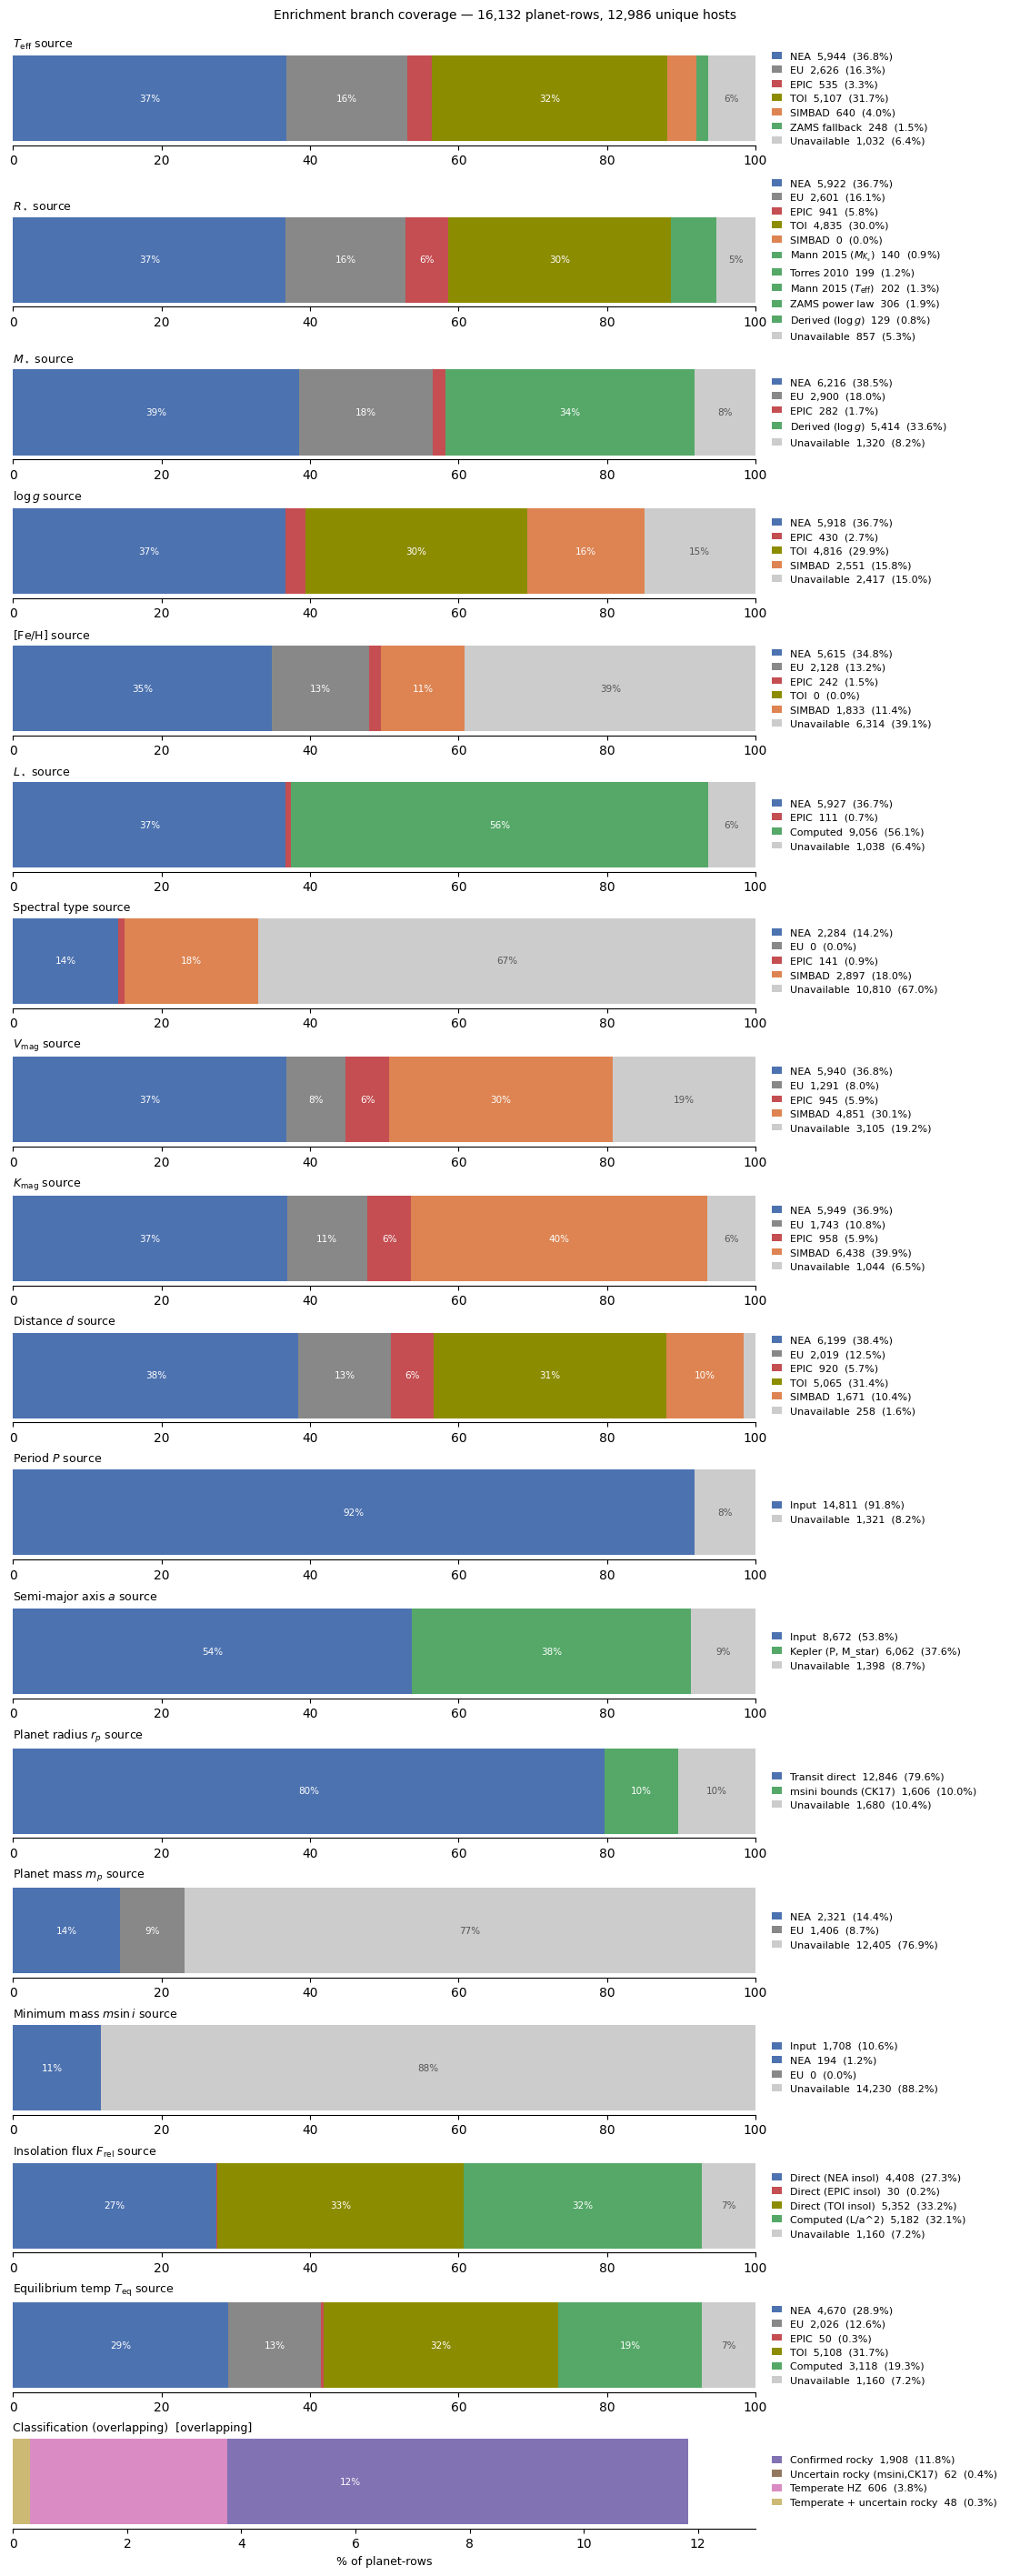

In [7]:
COLORS = {
    'NEA':                           '#4C72B0',
    'EPIC':                          '#C44E52',
    'TOI':                           '#8C8C00',
    'SIMBAD':                        '#DD8452',
    'ZAMS fallback':                 '#55A868',
    'Computed':                      '#55A868',
    'EMC direct':                    '#4C72B0',
    'Input':                         '#4C72B0',
    'Kepler (P, M_star)':            '#55A868',
    'Transit direct':                '#4C72B0',
    'msini bounds (CK17)':           '#55A868',
    'Direct (NEA insol)':            '#4C72B0',
    'Direct (EPIC insol)':           '#C44E52',
    'Direct (TOI insol)':            '#8C8C00',
    'Computed (L/a^2)':              '#55A868',
    'Confirmed rocky':               '#8172B3',
    'Uncertain rocky (msini,CK17)':  '#937860',
    'Temperate HZ':                  '#DA8BC3',
    'Temperate + uncertain rocky':   '#CCB974',
    'Unavailable':                   '#CCCCCC',
    'Derived ($\log g$)':            '#55A868',
    'Mann 2015 ($M_{K_s}$)':         '#55A868',
    'Mann 2015 ($T_\mathrm{eff}$)': '#55A868',
    'ZAMS power law':                '#55A868',
    'Torres 2010':                   '#55A868',
}

fig, axes = plt.subplots(len(branches), 1,
                         figsize=(11, 1.55 * len(branches)),
                         constrained_layout=True)

for ax, (stage, cats, overlapping) in zip(axes, branches):
    ax.set_title(stage + ('  [overlapping]' if overlapping else ''),
                 loc='left', fontsize=9, pad=3)
    left = 0.0
    for label, count in cats:
        pct = 100 * count / n
        color = COLORS.get(label, '#888')
        ax.barh(0, pct, left=left, color=color, height=0.55,
                label=f'{label}  {count:,}  ({pct:.1f}%)')
        if pct > 4:
            ax.text(left + pct / 2, 0, f'{pct:.0f}%',
                    ha='center', va='center', fontsize=7.5,
                    color='white' if label != 'Unavailable' else '#555')
        if not overlapping:
            left += pct
    ax.set_xlim(0, 100 if not overlapping else max(c for _, c in cats) * 100 / n * 1.1)
    ax.set_yticks([])
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
              fontsize=8, frameon=False, handlelength=1.0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if ax is axes[-1]:
        ax.set_xlabel('% of planet-rows', fontsize=9)

fig.suptitle(
    f'Enrichment branch coverage — {n:,} planet-rows, {n_hosts:,} unique hosts',
    fontsize=10, y=1.01,
)
plt.savefig('enrichment_branches.png', dpi=150, bbox_inches='tight')
plt.show()


exo-mercat_name,nasa_name,toi_name,epic_name,eu_name,oec_name,host,letter,main_id,binary,main_id_ra,main_id_dec,mass,mass_max,mass_min,mass_url,msini,msini_max,msini_min,msini_url,bestmass,bestmass_max,bestmass_min,bestmass_url,bestmass_provenance,p,p_max,p_min,p_url,r,r_max,r_min,r_url,a,a_max,a_min,a_url,e,e_max,e_min,e_url,i,i_max,i_min,i_url,discovery_method,status,checked_status_string,original_status_string,confirmed,discovery_year,main_id_aliases,main_id_provenance,angular_separation_flag,angular_separation,catalog,duplicate_catalog_flag,duplicate_names,binary_coordinate_mismatch_flag,binary_complex_system_flag,coordinate_mismatch_flag,coordinate_mismatch,period_mismatch_flag,fallback_merge_flag,misnamed_duplicates_flag,row_update
str39,str28,str11,str19,str31,str27,str29,str3,str36,str6,float64,float64,float64,float64,float64,str50,float64,float64,float64,str21,float64,float64,float64,str50,str5,float64,float64,float64,str67,float64,float64,float64,str67,float64,float64,float64,str67,float64,float64,float64,str67,float64,float64,float64,str67,str39,str14,str95,str95,int64,int64,str1562,str11,int64,str45,str20,int64,str101,int64,int64,int64,str3,int64,int64,int64,str10
* 2 Dra b,--,--,--,2 Dra b,--,2 Dra,b,* 2 Dra,--,174.01165101521,69.32295228569,--,--,--,--,0.585,0.061,0.062,eu,0.585,0.061,0.062,eu,Msini,340.6,1.38,1.33,eu,--,--,--,--,0.9905,0.0027,0.0026,eu,0.059,0.162,0.015,eu,--,--,--,--,Radial Velocity,CANDIDATE,eu: CANDIDATE,eu: CANDIDATE,0,2026,"* 2 Dra,2MASS J11360276+6919229,AG+69 482,ASCC 81950,BD+70 670,GC 15893,GCRV 7047,GSC 04392-00141,Gaia DR2 1061520550394795392,Gaia DR3 1061520550394795392,HD 100696,HIC 56583,HIP 56583,HR 4461,IRAS 11331+6935,IRC +70108,LSPM J1136+6919,PLX 2679,PLX 2679.00,PPM 17933,ROT 1723,SAO 15567,SKY# 21968,TIC 142827466,TYC 4392-141-1,USNO-B1.0 1593-00110441,WEB 10170",SIMBAD,0,eu: 0.0,eu,0,--,0,0,0,--,0,0,0,2026-05-31
* 4 Mon B .01,--,TOI-651.01,--,--,--,TIC 72090501,.01,* 4 Mon,B,92.10580911815,-11.14629063894,--,--,--,--,--,--,--,--,--,--,--,--,--,1.0697877,2.2e-06,2.2e-06,toi,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,Transit,CANDIDATE,toi: CANDIDATE,toi: CANDIDATE,0,2019,"* 4 Mon,* 4 Mon B,** BU 17A,** BU 17B,1RXS J060825.2-110843,2MASS J06082536-1108496,ADS 4741 A,ADS 4741 B,BD-11 1393,CCDM J06084-1109A,CCDM J06084-1109B,CSI-11 1393 1,GC 7810,Gaia DR1 3004190982007742208,Gaia DR2 3004190986305089536,Gaia DR2 3004190986305090048,Gaia DR2 3004190986305090176,Gaia DR3 3004190986305089536,Gaia DR3 3004190986305090176,HD 42116,HIC 29118,HIP 29118,IDS 06037-1108 A,PPM 216769,SAO 151154,SKY# 10281,TD1 6180,TIC 72090499,TIC 72090501,TIC-72090501,TOI-651,TYC 5366-2279-1,TYC 5366-2280-1,UCAC4 395-011524,WDS J06084-1109A,WDS J06084-1109B",SIMBAD,0,toi: 0.0,toi,0,--,0,0,0,--,0,0,0,2026-05-31
* 6 Lyn b,6 Lyn b,--,--,6 Lyn b,6 Lyn b,6 Lyn,b,* 6 Lyn,--,97.69628162561209,58.162633282470274,--,--,--,--,2.01,0.077,0.077,eu,2.01,0.077,0.077,eu,Msini,919.86,1.92,3.71,2023PASJ...75.1030T,--,--,--,--,2.028,0.003,0.005,2023PASJ...75.1030T,0.073,0.036,0.036,eu,2.0,79.0,1.0,oec,Radial Velocity,CONFIRMED,"eu: CONFIRMED,nasa: CONFIRMED,oec: CONFIRMED","eu: CONFIRMED,nasa: CONFIRMED,oec: CONFIRMED",3,2008,"* 6 Lyn,2MASS J06304711+5809453,6 Lyncis,AG+58 545,AP J06304711+5809453,ASCC 182129,BD+58 932,BD+58 932,CCDM J06309+5810A,CSI+58 932 1,DO 30475,GC 8416,GCRV 4140,GEN# +1.00045410,Gaia DR2 1004358968092652544,Gaia DR3 1004358968092652544,HD 45410,HD 45410,HIC 31039,HIP 31039,HR 2331,HR 2331,IDS 06220+5814 A,IRAS 06264+5811,LSPM J0630+5809,LTT 11856,N30 1407,NLTT 16571,PLX 1499,PLX 1499.00,PPM 30486,SAO 25771,SAO 25771,SKY# 11231,SPOCS 2671,TIC 444865362,TYC 3777-2071-1,UBV 6436,UBV M 12104,UCAC4 741-044033,USNO-B1.0 1481-00215981,WDS J06308+5810A,WEB 6178,YZ 58 4530,[B10] 1627,uvby98 100045410",SIMBAD,0,"eu: 0.0,nasa: 0.0,oec: 0.0","eu,nasa,oec",0,--,0,0,0,--,0,0,0,2026-05-31
* 8 UMi b,8 UMi b,--,--,8 Umi b,8 Ursae Minoris b,8 UMi,b,* 8 UMi,--,224.20146792993,74.90092254897,--,--,--,--,1.65,0.06,

In [8]:
from crossmatching import Crossmatcher, EMCCatalog, EMCIdSupplier

cme = Crossmatcher(EMCCatalog(), EMCIdSupplier())
cme.load_alternate_ids(emc["exo-mercat_name"], from_file="./input/exo-mercat.csv")

input_ids,id
str39,str29
